# Second impediment - images with tiny faces

## 1. Enroll users

In [1]:
import sys
from zipfile import Path; sys.path.insert(0, '..')
from src.model import get_insightface_model
from src.database import EmbeddingDB
from src.enrollment import enroll_from_folder
from pathlib import Path

sys.path.insert(0, '..')

NEW_DB_PATH = Path('../embeddings') / "chromadb_tinyface"
    
app = get_insightface_model('buffalo_l', ctx_id=0)
db = EmbeddingDB(NEW_DB_PATH)

In [2]:
results = enroll_from_folder('../data/tinyface_gallery_match', app, db, identities_in_dirs=False)
print(f'\nEnrolowanych użytkowników: {len(db)}')
print(f'Łącznie embeddingów: {sum(len(v) for v in db.get_all().values())}')

  1: already in DB, skipping.
  1000: already in DB, skipping.
  1004: already in DB, skipping.
  1005: already in DB, skipping.
  1006: already in DB, skipping.
  1007: already in DB, skipping.
  1008: already in DB, skipping.
  1015: already in DB, skipping.
  1016: already in DB, skipping.
  1018: already in DB, skipping.
  1020: already in DB, skipping.
  1027: already in DB, skipping.
  1033: already in DB, skipping.
  1034: already in DB, skipping.
  1035: already in DB, skipping.
  1036: already in DB, skipping.
  1037: already in DB, skipping.
  1038: already in DB, skipping.
  1039: already in DB, skipping.
  104: already in DB, skipping.
  1040: already in DB, skipping.
  1047: already in DB, skipping.
  1048: already in DB, skipping.
  1049: already in DB, skipping.
  1050: already in DB, skipping.
  1052: already in DB, skipping.
  1066: already in DB, skipping.
  1068: already in DB, skipping.
  1069: already in DB, skipping.
  107: already in DB, skipping.
  1070: already

## 2. Test authentication

In [2]:
import sys
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc, roc_curve, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding, cosine_similarity
from src.database import EmbeddingDB
from src.metrics import compute_far_frr, compute_roc, eer, plot_roc, plot_far_frr_vs_threshold
from src.utils import list_images

warnings.filterwarnings('ignore')

SEED             = 44
DEFAULT_THRESH   = 0.4
TEST_DIR         = Path('../data/tinyface_probe')

enrolled_users = set(db.get_all_users())
print(f'Enrolled users in DB : {len(enrolled_users)}')
print(f'Test directory       : {TEST_DIR.resolve()}')

Enrolled users in DB : 2569
Test directory       : /home/drzewo/szt_mag/face/data/tinyface_probe


In [3]:
# Collect all test images that belong to enrolled users
# Each entry: (user_id, embedding)

print('Extracting embeddings from test images...')

probes = []   # list of (user_id, embedding)

all_files = list_images(TEST_DIR)
grouped: dict[str, list[Path]] = {}

for file_path in all_files:
    # Extract identity_number from filename [identity_number]_[image_number].jpg
    stem = file_path.stem
    identity_number = stem.split('_')[0]
    
    if identity_number not in grouped:
        grouped[identity_number] = []
    grouped[identity_number].append(file_path)

for user_id in sorted(grouped.keys()):
    imgs = grouped[user_id]
    for img_path in imgs:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        emb = get_embedding(app, img, fallback=True)
        if emb is None:
            continue
        probes.append((user_id, emb))

print(f'Total valid probes : {len(probes)}')
print(f'Users with probes  : {len({uid for uid, _ in probes})}')

if len(probes) < 500:
    print(f'WARNING: only {len(probes)} probes — spec requires >= 500. '
          'Check enrolled_test/ or run enroll.py to rebuild the split.')

Extracting embeddings from test images...
Total valid probes : 3728
Users with probes  : 2563


In [4]:
SEED             = 44
DEFAULT_THRESH   = 0.4

user_list = sorted(enrolled_users)  # stable order for reproducible random sampling
rng = random.Random(SEED)

scores       = []
labels       = []
meta         = []   # (true_user_id, matched_user_id, pair_type)

for user_id, probe_emb in probes:
    # --- Genuine ---
    refs = db.get_user_embeddings(user_id)
    if refs:
        sim = max(float(np.dot(probe_emb, ref)) for ref in refs)
        scores.append(sim)
        labels.append(1)
        meta.append((user_id, user_id, 'genuine'))

    # --- Impostor (10 random different users per probe) ---
    candidates = [u for u in user_list if u != user_id]
    for impostor_id in rng.sample(candidates, min(10, len(candidates))):
        imp_refs = db.get_user_embeddings(impostor_id)
        if imp_refs:
            sim = max(float(np.dot(probe_emb, ref)) for ref in imp_refs)
            scores.append(sim)
            labels.append(0)
            meta.append((user_id, impostor_id, 'impostor'))

scores = np.array(scores)
labels = np.array(labels)

n_genuine  = int((labels == 1).sum())
n_impostor = int((labels == 0).sum())
print(f'Genuine  pairs : {n_genuine}')
print(f'Impostor pairs : {n_impostor}')
print(f'Total          : {len(scores)}')
print(f'Balance ratio  : {n_genuine / max(n_impostor, 1):.2f} (1.0 = perfect)')

Genuine  pairs : 3728
Impostor pairs : 37280
Total          : 41008
Balance ratio  : 0.10 (1.0 = perfect)


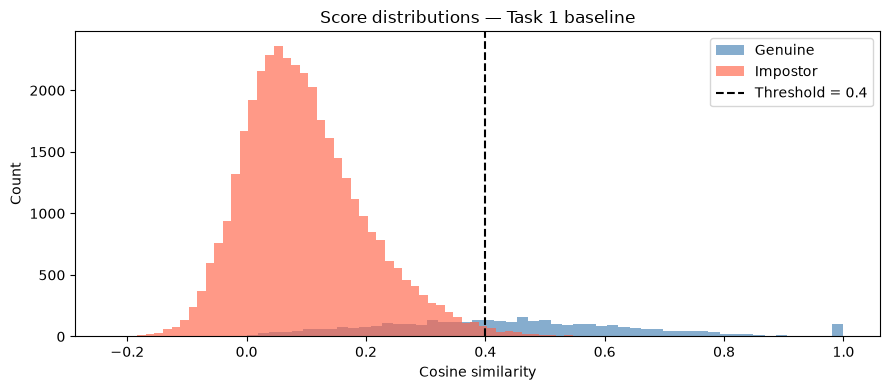

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(scores[labels == 1], bins=60, alpha=0.65, color='steelblue',  label='Genuine')
ax.hist(scores[labels == 0], bins=60, alpha=0.65, color='tomato',     label='Impostor')
ax.axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.5, label=f'Threshold = {DEFAULT_THRESH}')

ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Score distributions — Task 1 baseline')
ax.legend()
plt.tight_layout()

out_dir = Path('../results/task1')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'score_distributions.png', dpi=150)
plt.show()

In [6]:
far, frr, acc = compute_far_frr(scores, labels, DEFAULT_THRESH)

print(f'=== Metrics at threshold = {DEFAULT_THRESH} ===')
print(f'  FAR      : {far:.4f}  ({far*100:.2f}%)')
print(f'  FRR      : {frr:.4f}  ({frr*100:.2f}%)')
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')

=== Metrics at threshold = 0.4 ===
  FAR      : 0.0082  (0.82%)
  FRR      : 0.4603  (46.03%)
  Accuracy : 0.9507  (95.07%)


AUC : 0.9267
EER : 0.1484  (14.84%)  at threshold = 0.2027


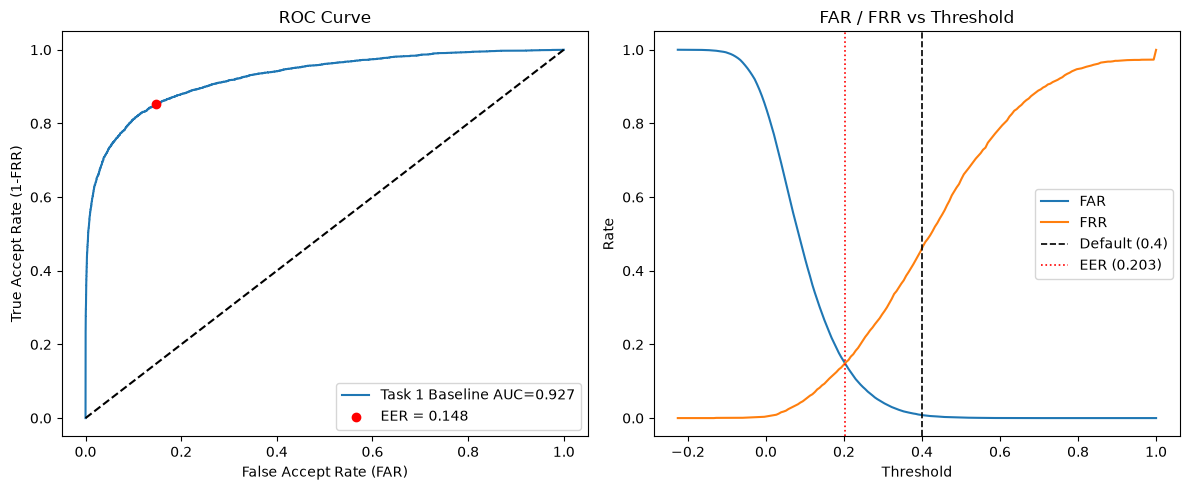

In [7]:
fpr, tpr, thresholds = compute_roc(scores, labels)
eer_val, eer_thresh  = eer(fpr, tpr, thresholds)
auc_val              = auc(fpr, tpr)

print(f'AUC : {auc_val:.4f}')
print(f'EER : {eer_val:.4f}  ({eer_val*100:.2f}%)  at threshold = {eer_thresh:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
plot_roc(fpr, tpr, ax=axes[0], label='Task 1 Baseline')
axes[0].scatter([eer_val], [1 - eer_val], color='red', zorder=5, label=f'EER = {eer_val:.3f}')
axes[0].legend()

# FAR / FRR vs threshold
plot_far_frr_vs_threshold(scores, labels, ax=axes[1])
axes[1].axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.2, label=f'Default ({DEFAULT_THRESH})')
axes[1].axvline(eer_thresh,     color='r', ls=':',  lw=1.2, label=f'EER ({eer_thresh:.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig(out_dir / 'roc_and_far_frr.png', dpi=150)
plt.show()

## 3. Attempt at improving FRR

In [1]:
import cv2
import numpy as np

from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet


def build_realesrgan(device="cuda"):
    model = RRDBNet(
        num_in_ch=3,
        num_out_ch=3,
        num_feat=64,
        num_block=23,
        num_grow_ch=32,
        scale=4,
    )

    upsampler = RealESRGANer(
        scale=4,
        model_path="../weights/RealESRGAN_x4plus.pth",
        model=model,
        tile=0,
        tile_pad=10,
        pre_pad=0,
        half=(device == "cuda"),
    )

    return upsampler


upsampler = build_realesrgan()

/home/drzewo/szt_mag/face/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
def enhance_face(img_bgr, upsampler):
    enhanced, _ = upsampler.enhance(
        img_bgr,
        outscale=2
    )

    return enhanced

In [10]:
from src.enrollment import enroll_user_averaged, list_images

def enroll_from_folder_limitted_enhanced(
    enrolled_dir: str | Path,
    app,
    db: EmbeddingDB,
    detect: bool = False,
    skip_existing: bool = True,
    limit = 30
) -> dict[str, int]:
    """
    Batch enroll all users from enrolled_dir/<user_id>/ structure.

    Each user ends up with exactly one averaged embedding in ChromaDB.

    Args:
        detect:        Whether to run face detection (see enroll_user_averaged).
        skip_existing: If True, users already present in ChromaDB are skipped.
                       If False, their embedding is removed and re-computed.

    Returns:
        dict {user_id: n_images_used}  (0 means no usable face found / skipped)
    """
    enrolled_dir = Path(enrolled_dir)
    existing = set(db.get_all_users())
    results = {}

    # Group all files by identity_number (prefix before first '_')
    all_files = list_images(enrolled_dir)
    grouped: dict[str, list[Path]] = {}

    user_count = 0
    
    for file_path in all_files:
        # Extract identity_number from filename [identity_number]_[image_number].jpg
        stem = file_path.stem
        identity_number = stem.split('_')[0]
        
        if identity_number not in grouped:
            grouped[identity_number] = []
        grouped[identity_number].append(file_path)
    
    # Enroll each group as a separate user
    for identity_number in sorted(grouped.keys()):
        user_id = identity_number
        
        if user_id in existing:
            if skip_existing:
                print(f"  {user_id}: already in DB, skipping.")
                results[user_id] = 0
                continue
            else:
                db.remove_user(user_id)
        
        images = [enhance_face(cv2.imread(str(p)), upsampler) for p in grouped[user_id]]
        images = [img for img in images if img is not None]
        
        if not images:
            print(f"  WARNING: no images found for {user_id}, skipping.")
            continue
        
        n = enroll_user_averaged(user_id, images, app, db, detect=detect)
        results[user_id] = n
        print(f"  {user_id}: averaged {n}/{len(images)} embeddings -> 1 vector stored")
        user_count += 1

        if user_count >= limit:
            print(f"Reached limit of {limit} users, stopping enrollment.")
            break

    return results

In [26]:
import sys
from zipfile import Path; sys.path.insert(0, '..')
from src.model import get_insightface_model
from src.database import EmbeddingDB
from src.enrollment import enroll_from_folder
from pathlib import Path

sys.path.insert(0, '..')

ANOTHER_NEW_DB_PATH = Path('../embeddings') / "chromadb_tinyface_enhanced"
    
app = get_insightface_model('buffalo_l', ctx_id=0)
db = EmbeddingDB(ANOTHER_NEW_DB_PATH)

In [12]:
results = enroll_from_folder_limitted_enhanced('../data/tinyface_gallery_match', app, db)
print(f'\nEnrolowanych użytkowników: {len(db)}')
print(f'Łącznie embeddingów: {sum(len(v) for v in db.get_all().values())}')

  1: averaged 9/9 embeddings -> 1 vector stored
  1000: averaged 1/1 embeddings -> 1 vector stored
  1004: averaged 3/3 embeddings -> 1 vector stored
  1005: averaged 2/2 embeddings -> 1 vector stored
  1006: averaged 1/1 embeddings -> 1 vector stored
  1007: averaged 3/3 embeddings -> 1 vector stored
  1008: averaged 2/2 embeddings -> 1 vector stored
  1015: averaged 3/3 embeddings -> 1 vector stored
  1016: averaged 2/2 embeddings -> 1 vector stored
  1018: averaged 1/1 embeddings -> 1 vector stored
  1020: averaged 1/1 embeddings -> 1 vector stored
  1027: averaged 2/2 embeddings -> 1 vector stored
  1033: averaged 2/2 embeddings -> 1 vector stored
  1034: averaged 5/5 embeddings -> 1 vector stored
  1035: averaged 4/4 embeddings -> 1 vector stored
  1036: averaged 4/4 embeddings -> 1 vector stored
  1037: averaged 4/4 embeddings -> 1 vector stored
  1038: averaged 2/2 embeddings -> 1 vector stored
  1039: averaged 3/3 embeddings -> 1 vector stored
  104: averaged 2/2 embeddings -> 

In [ ]:
import sys
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import auc, roc_curve, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, str(Path('..').resolve()))

from src.model import get_insightface_model, get_embedding, cosine_similarity
from src.database import EmbeddingDB
from src.metrics import compute_far_frr, compute_roc, eer, plot_roc, plot_far_frr_vs_threshold
from src.utils import list_images

warnings.filterwarnings('ignore')

SEED             = 44
DEFAULT_THRESH   = 0.2938
TEST_DIR         = Path('../data/tinyface_probe')

# Collect all test images that belong to enrolled users
# Each entry: (user_id, embedding)

print('Extracting embeddings from test images...')

probes = []   # list of (user_id, embedding)

all_files = list_images(TEST_DIR)
grouped: dict[str, list[Path]] = {}
existing = set(db.get_all_users())

for file_path in all_files:
    # Extract identity_number from filename [identity_number]_[image_number].jpg
    stem = file_path.stem
    identity_number = stem.split('_')[0]
    
    if identity_number not in existing:
        continue
    if identity_number not in grouped:
        grouped[identity_number] = []
    grouped[identity_number].append(file_path)

for user_id in sorted(grouped.keys()):
    imgs = grouped[user_id]
    for img_path in imgs:
        img = cv2.imread(str(img_path))
        img = enhance_face(img, upsampler)

        if img is None:
            continue

        emb = get_embedding(app, img, fallback=True)
        if emb is None:
            continue
        probes.append((user_id, emb))

print(f'Total valid probes : {len(probes)}')
print(f'Users with probes  : {len({uid for uid, _ in probes})}')

if len(probes) < 500:
    print(f'WARNING: only {len(probes)} probes — spec requires >= 500. '
          'Check enrolled_test/ or run enroll.py to rebuild the split.')

Extracting embeddings from test images...
Total valid probes : 69
Users with probes  : 30


In [27]:
SEED             = 44
DEFAULT_THRESH   = 0.2938

enrolled_users = set(db.get_all_users())

user_list = sorted(enrolled_users)  # stable order for reproducible random sampling
rng = random.Random(SEED)

scores       = []
labels       = []
meta         = []   # (true_user_id, matched_user_id, pair_type)

for user_id, probe_emb in probes:
    # --- Genuine ---
    refs = db.get_user_embeddings(user_id)
    if refs:
        sim = max(float(np.dot(probe_emb, ref)) for ref in refs)
        scores.append(sim)
        labels.append(1)
        meta.append((user_id, user_id, 'genuine'))

    # --- Impostor (10 random different users per probe) ---
    candidates = [u for u in user_list if u != user_id]
    for impostor_id in rng.sample(candidates, min(10, len(candidates))):
        imp_refs = db.get_user_embeddings(impostor_id)
        if imp_refs:
            sim = max(float(np.dot(probe_emb, ref)) for ref in imp_refs)
            scores.append(sim)
            labels.append(0)
            meta.append((user_id, impostor_id, 'impostor'))

scores = np.array(scores)
labels = np.array(labels)

n_genuine  = int((labels == 1).sum())
n_impostor = int((labels == 0).sum())
print(f'Genuine  pairs : {n_genuine}')
print(f'Impostor pairs : {n_impostor}')
print(f'Total          : {len(scores)}')
print(f'Balance ratio  : {n_genuine / max(n_impostor, 1):.2f} (1.0 = perfect)')

Genuine  pairs : 69
Impostor pairs : 690
Total          : 759
Balance ratio  : 0.10 (1.0 = perfect)


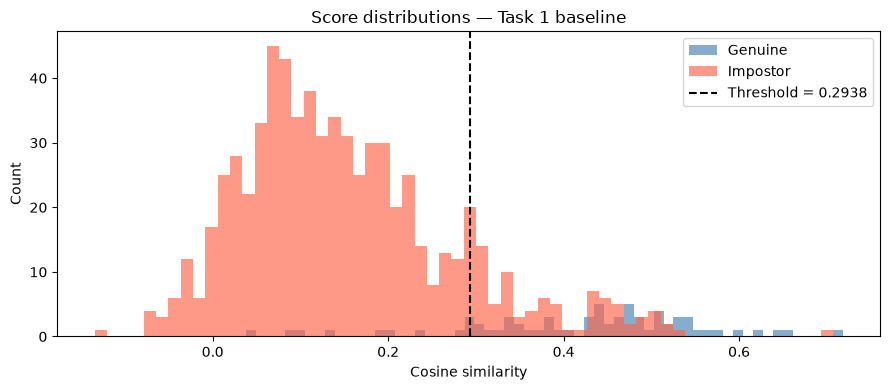

In [28]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(scores[labels == 1], bins=60, alpha=0.65, color='steelblue',  label='Genuine')
ax.hist(scores[labels == 0], bins=60, alpha=0.65, color='tomato',     label='Impostor')
ax.axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.5, label=f'Threshold = {DEFAULT_THRESH}')

ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Score distributions — Task 1 baseline')
ax.legend()
plt.tight_layout()

out_dir = Path('../results/task1')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'score_distributions.png', dpi=150)
plt.show()

In [37]:
far, frr, acc = compute_far_frr(scores, labels, 0.4)

print(f'=== Metrics at threshold = {DEFAULT_THRESH} ===')
print(f'  FAR      : {far:.4f}  ({far*100:.2f}%)')
print(f'  FRR      : {frr:.4f}  ({frr*100:.2f}%)')
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')

=== Metrics at threshold = 0.2938 ===
  FAR      : 0.0478  (4.78%)
  FRR      : 0.3768  (37.68%)
  Accuracy : 0.9223  (92.23%)


AUC : 0.9178
EER : 0.1275  (12.75%)  at threshold = 0.2938


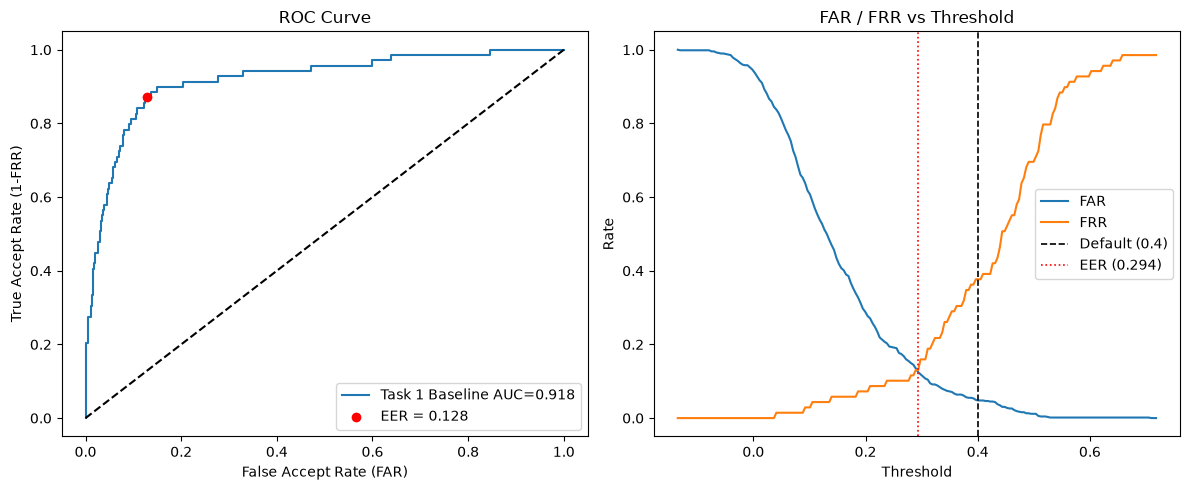

In [13]:
fpr, tpr, thresholds = compute_roc(scores, labels)
eer_val, eer_thresh  = eer(fpr, tpr, thresholds)
auc_val              = auc(fpr, tpr)

print(f'AUC : {auc_val:.4f}')
print(f'EER : {eer_val:.4f}  ({eer_val*100:.2f}%)  at threshold = {eer_thresh:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
plot_roc(fpr, tpr, ax=axes[0], label='Task 1 Baseline')
axes[0].scatter([eer_val], [1 - eer_val], color='red', zorder=5, label=f'EER = {eer_val:.3f}')
axes[0].legend()

# FAR / FRR vs threshold
plot_far_frr_vs_threshold(scores, labels, ax=axes[1])
axes[1].axvline(DEFAULT_THRESH, color='k', ls='--', lw=1.2, label=f'Default ({DEFAULT_THRESH})')
axes[1].axvline(eer_thresh,     color='r', ls=':',  lw=1.2, label=f'EER ({eer_thresh:.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig(out_dir / 'roc_and_far_frr.png', dpi=150)
plt.show()

## 4. Enhancemnt of authentication, enrollemnt without enhancement.

In [38]:
import sys
from zipfile import Path; sys.path.insert(0, '..')
from src.model import get_insightface_model
from src.database import EmbeddingDB
from src.enrollment import enroll_from_folder
from pathlib import Path

sys.path.insert(0, '..')

NEW_DB_PATH = Path('../embeddings') / "chromadb_tinyface"
    
app = get_insightface_model('buffalo_l', ctx_id=0)
db = EmbeddingDB(NEW_DB_PATH)

In [39]:
SEED             = 44
DEFAULT_THRESH   = 0.4

enrolled_users = set(db.get_all_users())

user_list = sorted(enrolled_users)  # stable order for reproducible random sampling
rng = random.Random(SEED)

scores       = []
labels       = []
meta         = []   # (true_user_id, matched_user_id, pair_type)

for user_id, probe_emb in probes:
    # --- Genuine ---
    refs = db.get_user_embeddings(user_id)
    if refs:
        sim = max(float(np.dot(probe_emb, ref)) for ref in refs)
        scores.append(sim)
        labels.append(1)
        meta.append((user_id, user_id, 'genuine'))

    # --- Impostor (10 random different users per probe) ---
    candidates = [u for u in user_list if u != user_id]
    for impostor_id in rng.sample(candidates, min(10, len(candidates))):
        imp_refs = db.get_user_embeddings(impostor_id)
        if imp_refs:
            sim = max(float(np.dot(probe_emb, ref)) for ref in imp_refs)
            scores.append(sim)
            labels.append(0)
            meta.append((user_id, impostor_id, 'impostor'))

scores = np.array(scores)
labels = np.array(labels)

n_genuine  = int((labels == 1).sum())
n_impostor = int((labels == 0).sum())
print(f'Genuine  pairs : {n_genuine}')
print(f'Impostor pairs : {n_impostor}')
print(f'Total          : {len(scores)}')
print(f'Balance ratio  : {n_genuine / max(n_impostor, 1):.2f} (1.0 = perfect)')

Genuine  pairs : 69
Impostor pairs : 690
Total          : 759
Balance ratio  : 0.10 (1.0 = perfect)


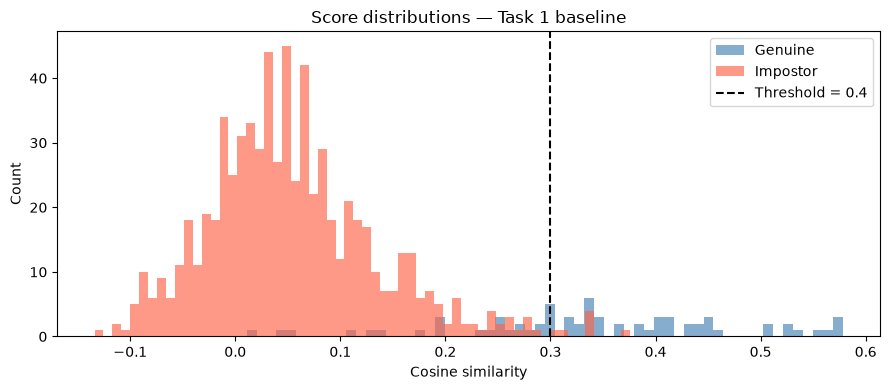

In [40]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(scores[labels == 1], bins=60, alpha=0.65, color='steelblue',  label='Genuine')
ax.hist(scores[labels == 0], bins=60, alpha=0.65, color='tomato',     label='Impostor')
ax.axvline(0.3, color='k', ls='--', lw=1.5, label=f'Threshold = {DEFAULT_THRESH}')

ax.set_xlabel('Cosine similarity')
ax.set_ylabel('Count')
ax.set_title('Score distributions — Task 1 baseline')
ax.legend()
plt.tight_layout()

out_dir = Path('../results/task1')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'score_distributions.png', dpi=150)
plt.show()

In [45]:
far, frr, acc = compute_far_frr(scores, labels, 0.25)

print(f'=== Metrics at threshold = {DEFAULT_THRESH} ===')
print(f'  FAR      : {far:.4f}  ({far*100:.2f}%)')
print(f'  FRR      : {frr:.4f}  ({frr*100:.2f}%)')
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')

=== Metrics at threshold = 0.4 ===
  FAR      : 0.0246  (2.46%)
  FRR      : 0.1884  (18.84%)
  Accuracy : 0.9605  (96.05%)


AUC : 0.9606
EER : 0.0783  (7.83%)  at threshold = 0.1786


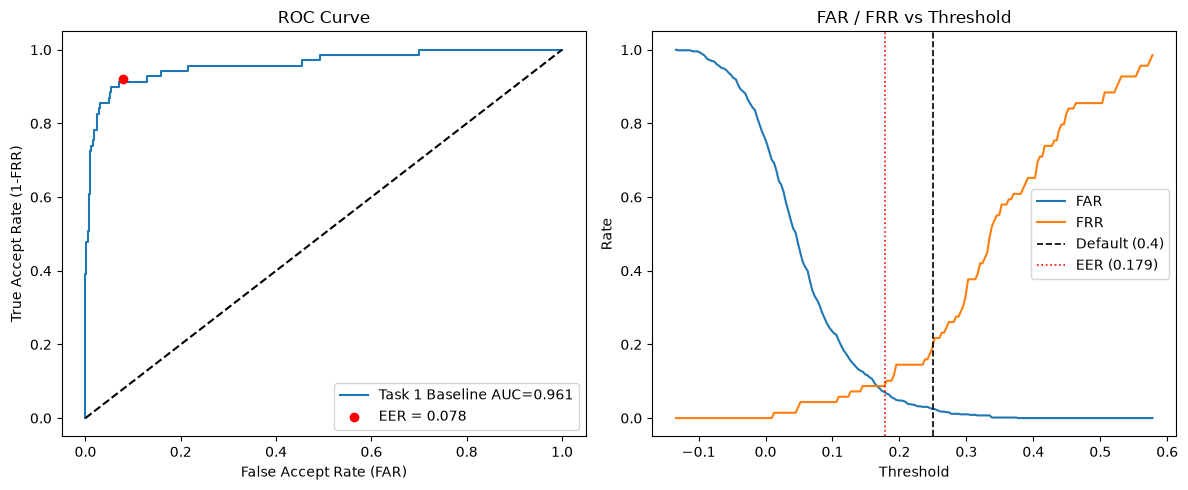

In [46]:
fpr, tpr, thresholds = compute_roc(scores, labels)
eer_val, eer_thresh  = eer(fpr, tpr, thresholds)
auc_val              = auc(fpr, tpr)

print(f'AUC : {auc_val:.4f}')
print(f'EER : {eer_val:.4f}  ({eer_val*100:.2f}%)  at threshold = {eer_thresh:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
plot_roc(fpr, tpr, ax=axes[0], label='Task 1 Baseline')
axes[0].scatter([eer_val], [1 - eer_val], color='red', zorder=5, label=f'EER = {eer_val:.3f}')
axes[0].legend()

# FAR / FRR vs threshold
plot_far_frr_vs_threshold(scores, labels, ax=axes[1])
axes[1].axvline(0.25, color='k', ls='--', lw=1.2, label=f'Default ({DEFAULT_THRESH})')
axes[1].axvline(eer_thresh,     color='r', ls=':',  lw=1.2, label=f'EER ({eer_thresh:.3f})')
axes[1].legend()

plt.tight_layout()
plt.savefig(out_dir / 'roc_and_far_frr.png', dpi=150)
plt.show()